# Module 7 — ATCNet-CIAM-3C for Harmonized MI-EEG

**Architecture:** ATCNet-style temporal attention + TCN + lightweight channel-integrated attention (CIAM), adapted to `(22, 640)` input and 3 classes.

**Training:** EEGMMIDB (109 subjects) as labeled source + BCI-IV-2a (9 subjects) as unlabeled target for optional unsupervised domain adaptation using DANN + CORAL + MMD.

**Evaluation:** final BCI-IV-2a labels are used only after adaptation.


In [1]:
# ============================================================
# CELL 1 — IMPORTS + REPRODUCIBILITY + DEVICE
# ============================================================

from __future__ import annotations

import os
import gc
import json
import copy
import math
import time
import random
import warnings
from pathlib import Path
from typing import Optional, Iterable

import numpy as np
import pandas as pd
import h5py
import scipy.signal as sig
from scipy.linalg import eigh

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    log_loss,
)
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")

SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything()

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)

print("Device:", device)

Device: mps


In [2]:
# ============================================================
# CELL 2 — AUTHORITATIVE PROJECT PATH DISCOVERY
# ============================================================
# The earlier modules define PROJECT_ROOT as:
#     /Users/ashokvarmabevara/Project2
#
# We preserve that path first, then provide safe fallbacks so
# the notebook can also run after the project directory has
# been moved/copied.

PROJECT_ROOT_CANDIDATES = [
    Path("/Users/ashokvarmabevara/Project2"),
    Path.cwd(),
    Path.home() / "Project2",
    Path("/mnt/data/Project2"),
]

PROJECT_ROOT = None

for candidate in PROJECT_ROOT_CANDIDATES:
    candidate = Path(candidate)
    if (
        (candidate / "cross_dataset_mi_project").exists()
        or (candidate / "BCI IV-2a").exists()
        or (candidate / "eegmmidb").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    # Last-resort explicit path from Modules 1–6.
    PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

OUTPUT_ROOT = PROJECT_ROOT / "cross_dataset_mi_project"
MANIFEST_ROOT = OUTPUT_ROOT / "manifests"
CACHE_ROOT = OUTPUT_ROOT / "cache"
RESULTS_ROOT = OUTPUT_ROOT / "results"
FIGURES_ROOT = OUTPUT_ROOT / "figures"
CHECKPOINT_ROOT = OUTPUT_ROOT / "checkpoints"

for p in [
    RESULTS_ROOT,
    FIGURES_ROOT,
    CHECKPOINT_ROOT,
]:
    p.mkdir(parents=True, exist_ok=True)

FINAL_CACHE_PATH = (
    CACHE_ROOT
    / "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT
    / "module_5_v2_preprocessing_specification.json"
)

MODULE_6_LOSO_PATH = (
    MANIFEST_ROOT
    / "module_6_within_dataset_loso_folds.csv"
)

MODULE_6_CACHE_META_PATH = (
    MANIFEST_ROOT
    / "module_6_cache_metadata.csv"
)

MODULE_6_PROTOCOL_PATH = (
    MANIFEST_ROOT
    / "module_6_baseline_protocol.json"
)

print("=" * 78)
print("MODULE 7 — PROJECT INTERFACE")
print("=" * 78)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Cache       :", FINAL_CACHE_PATH)
print("Manifest    :", MANIFEST_ROOT)
print("Results     :", RESULTS_ROOT)
print("Figures     :", FIGURES_ROOT)

print("\nExistence:")
for name, p in [
    ("PROJECT_ROOT", PROJECT_ROOT),
    ("OUTPUT_ROOT", OUTPUT_ROOT),
    ("FINAL_CACHE_PATH", FINAL_CACHE_PATH),
    ("MODULE_5_SPEC_PATH", MODULE_5_SPEC_PATH),
    ("MODULE_6_LOSO_PATH", MODULE_6_LOSO_PATH),
    ("MODULE_6_CACHE_META_PATH", MODULE_6_CACHE_META_PATH),
]:
    print(f"  {name:28s}: {'PASS' if p.exists() else 'FAIL'}")

MODULE 7 — PROJECT INTERFACE
PROJECT_ROOT: /Users/ashokvarmabevara/Project2
Cache       : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
Manifest    : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/manifests
Results     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results
Figures     : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/figures

Existence:
  PROJECT_ROOT                : PASS
  OUTPUT_ROOT                 : PASS
  FINAL_CACHE_PATH            : PASS
  MODULE_5_SPEC_PATH          : PASS
  MODULE_6_LOSO_PATH          : PASS
  MODULE_6_CACHE_META_PATH    : PASS


In [3]:
# ============================================================
# CELL 3 — LOAD THE FROZEN MODULE 5/6 CONTRACT
# ============================================================

with open(MODULE_5_SPEC_PATH, "r", encoding="utf-8") as f:
    module_5_spec = json.load(f)

FROZEN_CHANNELS = [str(x) for x in module_5_spec["channels"]]
TARGET_SFREQ = float(module_5_spec["target_sfreq_hz"])
LOW_HZ, HIGH_HZ = map(float, module_5_spec["primary_bandpass_hz"])
N_SAMPLES = int(module_5_spec["epoch"]["n_samples"])
TMIN = float(module_5_spec["epoch"]["tmin_sec"])
TMAX = float(module_5_spec["epoch"]["tmax_sec"])

# Explicit 3-class project interface from Module 6.
CLASSES = ["left", "right", "feet"]
CLASS_TO_ID = {c: i for i, c in enumerate(CLASSES)}
ID_TO_CLASS = {i: c for c, i in CLASS_TO_ID.items()}
N_CLASSES = len(CLASSES)

print(json.dumps({
    "channels": FROZEN_CHANNELS,
    "n_channels": len(FROZEN_CHANNELS),
    "sampling_rate_hz": TARGET_SFREQ,
    "bandpass_hz": [LOW_HZ, HIGH_HZ],
    "epoch_sec": [TMIN, TMAX],
    "n_samples": N_SAMPLES,
    "classes": CLASS_TO_ID,
}, indent=2))

assert len(FROZEN_CHANNELS) == 22
assert TARGET_SFREQ == 160.0
assert (LOW_HZ, HIGH_HZ) == (8.0, 30.0)
assert N_SAMPLES == 640
assert abs((TMAX - TMIN) - 4.0) < 1e-9
assert N_CLASSES == 3

print("\nFrozen Module 5/6 interface: PASS")

{
  "channels": [
    "Fz",
    "FC3",
    "FC1",
    "FCz",
    "FC2",
    "FC4",
    "C5",
    "C3",
    "C1",
    "Cz",
    "C2",
    "C4",
    "C6",
    "CP3",
    "CP1",
    "CPz",
    "CP2",
    "CP4",
    "P1",
    "Pz",
    "P2",
    "POz"
  ],
  "n_channels": 22,
  "sampling_rate_hz": 160.0,
  "bandpass_hz": [
    8.0,
    30.0
  ],
  "epoch_sec": [
    0.0,
    4.0
  ],
  "n_samples": 640,
  "classes": {
    "left": 0,
    "right": 1,
    "feet": 2
  }
}

Frozen Module 5/6 interface: PASS


In [4]:
# ============================================================
# CELL 4 — LOAD + VERIFY FINAL HDF5 CACHE METADATA
# ============================================================

REQUIRED_META = [
    "dataset",
    "subject",
    "run",
    "recording_id",
    "filename",
    "absolute_path",
    "harmonized_class",
    "event_index",
    "onset_sec",
    "source_sfreq_hz",
]

def decode_strings(values):
    result = []
    for v in values:
        if isinstance(v, bytes):
            result.append(v.decode("utf-8"))
        else:
            result.append(str(v))
    return result

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_shape = tuple(h5["X"].shape)
    X_dtype = str(h5["X"].dtype)
    meta_keys = list(h5["metadata"].keys())

    missing = [k for k in REQUIRED_META if k not in meta_keys]
    cache_attrs = {k: h5.attrs[k] for k in h5.attrs.keys()}

    metadata = {}
    for key in [
        "dataset", "subject", "run", "recording_id",
        "filename", "absolute_path", "harmonized_class"
    ]:
        metadata[key] = decode_strings(h5["metadata"][key][:])

    metadata["event_index"] = h5["metadata"]["event_index"][:].astype(np.int64)
    metadata["onset_sec"] = h5["metadata"]["onset_sec"][:].astype(np.float64)
    metadata["source_sfreq_hz"] = h5["metadata"]["source_sfreq_hz"][:].astype(np.float64)

cache_meta_df = pd.DataFrame(metadata)
cache_meta_df.insert(0, "cache_index", np.arange(len(cache_meta_df), dtype=np.int64))

print("=" * 78)
print("CACHE CONTRACT")
print("=" * 78)
print("Shape :", X_shape)
print("Dtype :", X_dtype)
print("Epochs:", len(cache_meta_df))
print("Meta  :", meta_keys)

assert not missing, f"Missing metadata: {missing}"
assert X_shape[1:] == (22, 640)
assert X_dtype == "float32"
assert set(cache_meta_df["harmonized_class"].unique()) == set(CLASSES)
assert cache_meta_df["subject"].nunique() == 118

dataset_summary = (
    cache_meta_df
    .groupby(["dataset", "harmonized_class"])
    .size()
    .unstack(fill_value=0)
)

display(dataset_summary)

print("\n118-subject / 3-class / 22×640 cache contract: PASS")

CACHE CONTRACT
Shape : (9316, 22, 640)
Dtype : float32
Epochs: 9316
Meta  : ['absolute_path', 'dataset', 'event_index', 'filename', 'harmonized_class', 'onset_sec', 'recording_id', 'run', 'source_sfreq_hz', 'subject']


harmonized_class,feet,left,right
dataset,,,
BCI-IV-2a,648,648,648
EEGMMIDB,2455,2479,2438



118-subject / 3-class / 22×640 cache contract: PASS


In [5]:
# ============================================================
# CELL 5 — FIXED NUMERICAL QA + CACHE LOAD
# ============================================================
# Loads the authoritative Module-6 HDF5 cache first, then
# performs numerical QA.
#
# Module-6 cache:
#   X              -> EEG epochs
#   metadata       -> labels / subjects / dataset information
#
# Expected:
#   9316 epochs
#   22 channels
#   640 samples
#   118 subjects
#   3 classes
# ============================================================

import os
import json
import h5py
import numpy as np
import pandas as pd

print("=" * 72)
print("MODULE 7 — NUMERICAL QA + CACHE LOAD")
print("=" * 72)

# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

from pathlib import Path

PROJECT_ROOT = Path("/Users/ashokvarmabevara/Project2")

# Allow execution from another machine/path if PROJECT_ROOT
# was already defined in an earlier notebook cell.
if "PROJECT_ROOT" in globals():
    PROJECT_ROOT = Path(PROJECT_ROOT)

PROJECT_DIR = PROJECT_ROOT / "cross_dataset_mi_project"
CACHE_ROOT = PROJECT_DIR / "cache"
MANIFEST_ROOT = PROJECT_DIR / "manifests"

FINAL_CACHE_PATH = (
    CACHE_ROOT /
    "module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5"
)

MODULE_5_SPEC_PATH = (
    MANIFEST_ROOT /
    "module_5_v2_preprocessing_specification.json"
)

CACHE_META_PATH = (
    MANIFEST_ROOT /
    "module_6_cache_metadata.csv"
)

print("\nProject root:")
print(PROJECT_ROOT)

print("\nCache:")
print(FINAL_CACHE_PATH)

# ------------------------------------------------------------
# 2. Validate paths
# ------------------------------------------------------------

if not FINAL_CACHE_PATH.exists():
    raise FileNotFoundError(
        "\nModule-6 cache was not found:\n"
        f"{FINAL_CACHE_PATH}\n\n"
        "Check PROJECT_ROOT in this cell."
    )

print("\nCache exists: YES")

# ------------------------------------------------------------
# 3. Load Module-5 specification if available
# ------------------------------------------------------------

module_5_spec = {}

if MODULE_5_SPEC_PATH.exists():
    with open(MODULE_5_SPEC_PATH, "r") as f:
        module_5_spec = json.load(f)

print(
    "Module-5 specification:",
    "FOUND" if MODULE_5_SPEC_PATH.exists() else "NOT FOUND"
)

# ------------------------------------------------------------
# 4. Inspect HDF5 structure
# ------------------------------------------------------------

with h5py.File(FINAL_CACHE_PATH, "r") as h5:

    print("\nHDF5 datasets/groups:")

    def print_h5(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"  {name:<35} "
                f"shape={obj.shape} "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"  {name}/")

    h5.visititems(print_h5)

    assert "X" in h5, (
        "Authoritative cache does not contain dataset 'X'."
    )

    X_shape = tuple(h5["X"].shape)

print("\nCache X shape:", X_shape)

# ------------------------------------------------------------
# 5. Load EEG data
# ------------------------------------------------------------
# Module 6 defines the authoritative EEG array as h5["X"].
# Load it into RAM for Module 7.

with h5py.File(FINAL_CACHE_PATH, "r") as h5:
    X_raw = np.asarray(
        h5["X"][:],
        dtype=np.float32
    )

print(
    f"\nX_raw loaded successfully: "
    f"{X_raw.shape}, dtype={X_raw.dtype}"
)

# ------------------------------------------------------------
# 6. Load metadata
# ------------------------------------------------------------

if CACHE_META_PATH.exists():

    cache_meta_df = pd.read_csv(CACHE_META_PATH)

    print(
        "\nMetadata rows:",
        len(cache_meta_df)
    )

else:

    # Fall back to metadata stored inside HDF5.
    print(
        "\nWARNING: module_6_cache_metadata.csv not found."
    )

    with h5py.File(FINAL_CACHE_PATH, "r") as h5:

        assert "metadata" in h5, (
            "No CSV metadata and no HDF5 metadata group found."
        )

        metadata = {}

        for key in h5["metadata"].keys():

            arr = h5["metadata"][key][:]

            if arr.dtype.kind in {"S", "O"}:
                arr = np.array(
                    [
                        x.decode("utf-8")
                        if isinstance(x, bytes)
                        else str(x)
                        for x in arr
                    ]
                )

            metadata[key] = arr

    cache_meta_df = pd.DataFrame(metadata)

print("\nMetadata columns:")
print(cache_meta_df.columns.tolist())

# ------------------------------------------------------------
# 7. Resolve labels
# ------------------------------------------------------------

LABEL_CANDIDATES = [
    "label",
    "labels",
    "class",
    "harmonized_class",
]

label_col = None

for c in LABEL_CANDIDATES:
    if c in cache_meta_df.columns:
        label_col = c
        break

if label_col is None:
    raise KeyError(
        "Could not locate class labels in cache metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

# Text class labels → integer labels
if cache_meta_df[label_col].dtype.kind in {"U", "S", "O"}:

    class_names = sorted(
        cache_meta_df[label_col]
        .astype(str)
        .unique()
        .tolist()
    )

    class_to_id = {
        name: i
        for i, name in enumerate(class_names)
    }

    y = (
        cache_meta_df[label_col]
        .astype(str)
        .map(class_to_id)
        .to_numpy(dtype=np.int64)
    )

    CLASSES = class_names

else:

    y = cache_meta_df[label_col].to_numpy(
        dtype=np.int64
    )

    unique_labels = sorted(
        np.unique(y).tolist()
    )

    # Preserve explicit class names when available.
    CLASSES = [str(x) for x in unique_labels]

print("\nLabel column:", label_col)
print("Classes:", CLASSES)
print("Encoded labels:", np.unique(y))

# ------------------------------------------------------------
# 8. Resolve subject IDs
# ------------------------------------------------------------

SUBJECT_CANDIDATES = [
    "subject",
    "subject_id",
    "subject_uid",
]

subject_col = None

for c in SUBJECT_CANDIDATES:
    if c in cache_meta_df.columns:
        subject_col = c
        break

if subject_col is None:
    raise KeyError(
        "Could not locate subject IDs in metadata.\n"
        f"Available columns: {cache_meta_df.columns.tolist()}"
    )

subjects = (
    cache_meta_df[subject_col]
    .astype(str)
    .to_numpy()
)

# ------------------------------------------------------------
# 9. Resolve dataset IDs
# ------------------------------------------------------------

DATASET_CANDIDATES = [
    "dataset",
    "dataset_name",
    "source_dataset",
]

dataset_col = None

for c in DATASET_CANDIDATES:
    if c in cache_meta_df.columns:
        dataset_col = c
        break

if dataset_col is not None:

    datasets = (
        cache_meta_df[dataset_col]
        .astype(str)
        .to_numpy()
    )

else:

    datasets = np.array(
        ["unknown"] * len(y),
        dtype=str
    )

# ------------------------------------------------------------
# 10. Basic consistency checks
# ------------------------------------------------------------

assert len(X_raw) == len(y), (
    f"X/y mismatch: {len(X_raw)} vs {len(y)}"
)

assert len(X_raw) == len(subjects), (
    f"X/subject mismatch: "
    f"{len(X_raw)} vs {len(subjects)}"
)

assert X_raw.ndim == 3, (
    f"Expected X=(N,C,T), got {X_raw.shape}"
)

N_EPOCHS, N_CHANNELS, N_SAMPLES = X_raw.shape

print("\nData interface:")
print(f"  epochs     : {N_EPOCHS}")
print(f"  channels   : {N_CHANNELS}")
print(f"  samples    : {N_SAMPLES}")
print(f"  classes    : {len(CLASSES)}")
print(f"  subjects   : {len(np.unique(subjects))}")

# ------------------------------------------------------------
# 11. Numerical QA
# ------------------------------------------------------------

nonfinite_mask = ~np.isfinite(X_raw)
nonfinite = int(nonfinite_mask.sum())

epoch_var = np.var(
    X_raw,
    axis=(1, 2)
)

zero_var_mask = epoch_var <= 1e-12
zero_var = int(zero_var_mask.sum())

print("\nNumerical QA:")
print(f"  Non-finite values   : {nonfinite}")
print(f"  Zero-variance epochs: {zero_var}")

# Non-finite values are a hard failure.
assert nonfinite == 0, (
    f"Found {nonfinite} non-finite values."
)

# Zero variance is a diagnostic condition, NOT an assertion.
print(
    "\nNumerical QA: PASS"
)

print(
    f"Zero-variance epochs retained in frozen cache: "
    f"{zero_var}"
)

# ------------------------------------------------------------
# 12. Dataset statistics
# ------------------------------------------------------------

print("\nClass distribution:")

class_counts = pd.Series(
    y
).value_counts().sort_index()

for cls_id, count in class_counts.items():

    cls_name = (
        CLASSES[int(cls_id)]
        if int(cls_id) < len(CLASSES)
        else str(cls_id)
    )

    print(
        f"  {cls_id} ({cls_name}): {count}"
    )

# ------------------------------------------------------------
# 13. Subject statistics
# ------------------------------------------------------------

subject_dataset = pd.DataFrame({
    "subject": subjects,
    "dataset": datasets,
})

subject_dataset["epochs"] = 1

subject_dataset = (
    subject_dataset
    .groupby(
        ["dataset", "subject"],
        as_index=False
    )["epochs"]
    .sum()
)

print("\nDataset / subject epoch statistics:")

display(
    subject_dataset.groupby("dataset")["epochs"]
    .agg(
        subjects="count",
        min_epochs="min",
        median_epochs="median",
        mean_epochs="mean",
        max_epochs="max",
    )
    .reset_index()
)

# ------------------------------------------------------------
# 14. Store zero-variance indices
# ------------------------------------------------------------

ZERO_VAR_INDICES = np.flatnonzero(
    zero_var_mask
).astype(np.int64)

ZERO_VAR_MASK = zero_var_mask

print(
    "\nZERO_VAR_INDICES:",
    len(ZERO_VAR_INDICES)
)

# ------------------------------------------------------------
# 15. Final interface summary
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("MODULE 7 DATA INTERFACE READY")
print("=" * 72)

print(f"Cache      : {FINAL_CACHE_PATH}")
print(f"X_raw      : {X_raw.shape}")
print(f"Labels     : {y.shape}")
print(f"Subjects   : {subjects.shape}")
print(f"Datasets   : {datasets.shape}")
print(f"Classes    : {CLASSES}")
print(f"Zero-var   : {zero_var}")
print(f"Nonfinite  : {nonfinite}")

print("\n✅ Cell 5 completed successfully.")

MODULE 7 — NUMERICAL QA + CACHE LOAD

Project root:
/Users/ashokvarmabevara/Project2

Cache:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5

Cache exists: YES
Module-5 specification: FOUND

HDF5 datasets/groups:
  X                                   shape=(9316, 22, 640) dtype=float32
  metadata/
  metadata/absolute_path              shape=(9316,) dtype=object
  metadata/dataset                    shape=(9316,) dtype=object
  metadata/event_index                shape=(9316,) dtype=int64
  metadata/filename                   shape=(9316,) dtype=object
  metadata/harmonized_class           shape=(9316,) dtype=object
  metadata/onset_sec                  shape=(9316,) dtype=float64
  metadata/recording_id               shape=(9316,) dtype=object
  metadata/run                        shape=(9316,) dtype=object
  metadata/source_sfreq_hz            shape=(9316,) dtype=float64
  metadata/subject                    sh

,dataset,subjects,min_epochs,median_epochs,mean_epochs,max_epochs
0,BCI-IV-2a,9,216,216.0,216.000000,216
1,EEGMMIDB,109,54,68.0,67.633028,85



ZERO_VAR_INDICES: 0

MODULE 7 DATA INTERFACE READY
Cache      : /Users/ashokvarmabevara/Project2/cross_dataset_mi_project/cache/module_5_v2_preprocessed_epochs_160hz_8_30hz_continuous.h5
X_raw      : (9316, 22, 640)
Labels     : (9316,)
Subjects   : (9316,)
Datasets   : (9316,)
Classes    : ['feet', 'left', 'right']
Zero-var   : 0
Nonfinite  : 0

✅ Cell 5 completed successfully.


In [6]:
# ============================================================
# CELL 6 — LEAKAGE-SAFE SOURCE-ONLY ROBUST NORMALIZATION
# ============================================================

class SourceOnlyRobustNormalizer:
    def __init__(self, eps=1e-6):
        self.eps = float(eps)
        self.median_ = None
        self.iqr_ = None
        self.fitted_subjects_ = tuple()

    def fit(self, X_source, source_subjects):
        X_source = np.asarray(X_source, dtype=np.float64)
        source_subjects = [str(s) for s in source_subjects]

        if X_source.ndim != 3 or X_source.shape[1:] != (22, 640):
            raise ValueError(f"Expected (N,22,640), got {X_source.shape}")

        values = X_source.transpose(1, 0, 2).reshape(22, -1)

        self.median_ = np.median(values, axis=1)
        q25 = np.percentile(values, 25, axis=1)
        q75 = np.percentile(values, 75, axis=1)
        self.iqr_ = np.maximum(q75 - q25, self.eps)

        self.fitted_subjects_ = tuple(sorted(set(source_subjects)))
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=np.float32)
        return (
            (X - self.median_[None, :, None])
            / (self.iqr_[None, :, None] + self.eps)
        ).astype(np.float32)

    def assert_target_excluded(self, target_subject):
        if str(target_subject) in set(self.fitted_subjects_):
            raise AssertionError(
                f"LEAKAGE: {target_subject} was used for normalization."
            )

print("Normalizer: ready")

Normalizer: ready


In [7]:
# ============================================================
# CELL 7 — HDF5 RANDOM-ACCESS HELPERS
# ============================================================

class HDF5EpochStore:
    def __init__(self, path):
        self.path = Path(path)
        self._h5 = None

    def __enter__(self):
        self._h5 = h5py.File(self.path, "r")
        return self

    def __exit__(self, exc_type, exc, tb):
        if self._h5 is not None:
            self._h5.close()
            self._h5 = None

    @property
    def shape(self):
        return tuple(self._h5["X"].shape)

    def get_X(self, indices):
        indices = np.asarray(indices, dtype=np.int64)
        order = np.argsort(indices)
        sorted_idx = indices[order]
        values = np.asarray(self._h5["X"][sorted_idx], dtype=np.float32)
        return values[np.argsort(order)]

def load_indices(indices):
    with HDF5EpochStore(FINAL_CACHE_PATH) as store:
        return store.get_X(indices)

print("HDF5 loader:", load_indices([0, 1]).shape)

HDF5 loader: (2, 22, 640)


In [8]:
# ============================================================
# CELL 8 — SUBJECT-WISE FOLDS + INNER VALIDATION
# ============================================================

def parse_json_indices(s):
    return np.asarray(json.loads(s), dtype=np.int64)

# Prefer Module 6's authoritative LOSO manifest when available.
if MODULE_6_LOSO_PATH.exists():
    within_loso_df = pd.read_csv(MODULE_6_LOSO_PATH)
else:
    rows = []
    for dataset_name in sorted(cache_meta_df["dataset"].unique()):
        ds = cache_meta_df[cache_meta_df["dataset"] == dataset_name]
        for fold_id, target_subject in enumerate(sorted(ds["subject"].unique())):
            train_idx = ds.loc[ds["subject"] != target_subject, "cache_index"].tolist()
            test_idx = ds.loc[ds["subject"] == target_subject, "cache_index"].tolist()
            rows.append({
                "protocol": "within_dataset_loso",
                "dataset": dataset_name,
                "fold_id": fold_id,
                "target_subject": target_subject,
                "train_indices_json": json.dumps(train_idx),
                "test_indices_json": json.dumps(test_idx),
            })
    within_loso_df = pd.DataFrame(rows)

# Normalize manifest column naming across versions.
if "target_subject" not in within_loso_df.columns:
    raise RuntimeError("Module 6 LOSO manifest has no target_subject column.")

print("Within-dataset folds:", len(within_loso_df))
display(within_loso_df[[
    "dataset", "fold_id", "target_subject",
    "source_train_subject_count" if "source_train_subject_count" in within_loso_df.columns else "target_subject"
]].head())

def make_inner_subject_split(train_subjects, seed=SEED, val_fraction=0.20):
    subjects = np.array(sorted(set(map(str, train_subjects))))
    rng = np.random.default_rng(seed)
    rng.shuffle(subjects)

    n_val = max(1, int(round(len(subjects) * val_fraction)))
    n_val = min(n_val, len(subjects) - 1)

    return set(subjects[n_val:]), set(subjects[:n_val])

def make_balanced_sample_weights(y):
    y = np.asarray(y, dtype=np.int64)
    counts = np.bincount(y, minlength=N_CLASSES).astype(np.float64)
    weights = np.zeros_like(counts)
    weights[counts > 0] = 1.0 / counts[counts > 0]
    return weights[y]

print("Inner validation splitter: ready")

Within-dataset folds: 118


,dataset,fold_id,target_subject,source_train_subject_count
0,BCI-IV-2a,0,S01,8
1,BCI-IV-2a,1,S02,8
2,BCI-IV-2a,2,S03,8
3,BCI-IV-2a,3,S04,8
4,BCI-IV-2a,4,S05,8


Inner validation splitter: ready


In [9]:
# ============================================================
# CELL 9 — DATASET SUMMARY + TRANSFER SPLIT
# ============================================================

SOURCE_DATASET = "EEGMMIDB"
TARGET_DATASET = "BCI-IV-2a"

source_df = cache_meta_df[
    cache_meta_df["dataset"].astype(str) == SOURCE_DATASET
].copy()
target_df = cache_meta_df[
    cache_meta_df["dataset"].astype(str) == TARGET_DATASET
].copy()

source_subjects = sorted(
    source_df["subject"].astype(str).unique()
)
target_subjects = sorted(
    target_df["subject"].astype(str).unique()
)

print("=" * 78)
print("ATCNet-CIAM TRANSFER SETUP")
print("=" * 78)
print("Source dataset :", SOURCE_DATASET)
print("Source subjects:", len(source_subjects))
print("Target dataset :", TARGET_DATASET)
print("Target subjects:", len(target_subjects))

assert len(source_subjects) == 109, len(source_subjects)
assert len(target_subjects) == 9, len(target_subjects)

print("\nSource class counts:")
display(
    source_df["harmonized_class"].value_counts()
    .reindex(CLASSES, fill_value=0)
    .rename("epochs")
    .to_frame()
)

print("Target class counts:")
display(
    target_df["harmonized_class"].value_counts()
    .reindex(CLASSES, fill_value=0)
    .rename("epochs")
    .to_frame()
)

# Source-only inner validation split: target BCI remains external.
source_train_subjects, source_val_subjects = make_inner_subject_split(
    source_subjects,
    seed=SEED,
    val_fraction=0.20,
)

source_train_subjects = sorted(map(str, source_train_subjects))
source_val_subjects = sorted(map(str, source_val_subjects))

train_mask = (
    (cache_meta_df["dataset"].astype(str) == SOURCE_DATASET)
    & cache_meta_df["subject"].astype(str).isin(source_train_subjects)
)
val_mask = (
    (cache_meta_df["dataset"].astype(str) == SOURCE_DATASET)
    & cache_meta_df["subject"].astype(str).isin(source_val_subjects)
)
target_mask = (
    cache_meta_df["dataset"].astype(str) == TARGET_DATASET
)

SOURCE_TRAIN_IDX = cache_meta_df.loc[train_mask, "cache_index"].to_numpy(np.int64)
SOURCE_VAL_IDX = cache_meta_df.loc[val_mask, "cache_index"].to_numpy(np.int64)
TARGET_IDX = cache_meta_df.loc[target_mask, "cache_index"].to_numpy(np.int64)

X_source_train_raw = load_indices(SOURCE_TRAIN_IDX)
X_source_val_raw = load_indices(SOURCE_VAL_IDX)
X_target_raw = load_indices(TARGET_IDX)

y_source_train = (
    cache_meta_df.loc[train_mask, "harmonized_class"]
    .map(CLASS_TO_ID)
    .to_numpy(np.int64)
)
y_source_val = (
    cache_meta_df.loc[val_mask, "harmonized_class"]
    .map(CLASS_TO_ID)
    .to_numpy(np.int64)
)
y_target = (
    cache_meta_df.loc[target_mask, "harmonized_class"]
    .map(CLASS_TO_ID)
    .to_numpy(np.int64)
)

source_train_ids = (
    cache_meta_df.loc[train_mask, "subject"].astype(str).to_numpy()
)

assert len(X_source_train_raw) == len(y_source_train) == len(source_train_ids)
assert len(X_source_val_raw) == len(y_source_val)
assert len(X_target_raw) == len(y_target)

print("\nShapes:")
print("  source train:", X_source_train_raw.shape)
print("  source val  :", X_source_val_raw.shape)
print("  target test :", X_target_raw.shape)

print("\nTarget BCI labels are stored separately and are not used in training.")


ATCNet-CIAM TRANSFER SETUP
Source dataset : EEGMMIDB
Source subjects: 109
Target dataset : BCI-IV-2a
Target subjects: 9

Source class counts:


,epochs
harmonized_class,
feet,2455
left,2479
right,2438


Target class counts:


,epochs
harmonized_class,
feet,648
left,648
right,648



Shapes:
  source train: (5886, 22, 640)
  source val  : (1486, 22, 640)
  target test : (1944, 22, 640)

Target BCI labels are stored separately and are not used in training.


In [10]:
# ============================================================
# CELL 10 — SOURCE-ONLY NORMALIZATION + CLEANING
# ============================================================

# Remove constant/near-constant epochs only from source training.
src_std = np.std(X_source_train_raw, axis=(1, 2))
src_keep = np.isfinite(src_std) & (src_std >= 1e-6)

print("Constant source-training epochs removed:", int((~src_keep).sum()))

X_source_train = X_source_train_raw[src_keep]
y_source_train_clean = y_source_train[src_keep]
source_train_ids_clean = source_train_ids[src_keep]

# Fit normalization only on labeled source training subjects.
source_normalizer = SourceOnlyRobustNormalizer().fit(
    X_source_train,
    source_train_ids_clean,
)

# Target BCI is never part of the fit.
source_normalizer.assert_target_excluded("__BCI_EXTERNAL_TARGET__")

X_source_train_n = np.nan_to_num(
    source_normalizer.transform(X_source_train),
    nan=0.0, posinf=0.0, neginf=0.0
).astype(np.float32)

X_source_val_n = np.nan_to_num(
    source_normalizer.transform(X_source_val_raw),
    nan=0.0, posinf=0.0, neginf=0.0
).astype(np.float32)

X_target_n = np.nan_to_num(
    source_normalizer.transform(X_target_raw),
    nan=0.0, posinf=0.0, neginf=0.0
).astype(np.float32)

print("Normalized:")
print("  train:", X_source_train_n.shape)
print("  val  :", X_source_val_n.shape)
print("  BCI  :", X_target_n.shape)

assert X_source_train_n.shape[1:] == (22, 640)
assert X_source_val_n.shape[1:] == (22, 640)
assert X_target_n.shape[1:] == (22, 640)


Constant source-training epochs removed: 0
Normalized:
  train: (5886, 22, 640)
  val  : (1486, 22, 640)
  BCI  : (1944, 22, 640)


In [11]:
# ============================================================
# CELL 11 — ATCNet-CIAM-3C ARCHITECTURE
# ============================================================
# Adaptation of the ATCNet design:
#   temporal conv -> spatial filtering -> sliding windows
#   -> multi-head self-attention + TCN -> attention fusion
# plus lightweight CIAM channel attention.
#
# Adapted for:
#   N x 22 x 640
#   3 classes
# ============================================================

class GradientReversalFn(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambd):
        ctx.lambd = float(lambd)
        return x.view_as(x)

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambd * grad_output, None


class GradientReversal(nn.Module):
    def forward(self, x, lambd=1.0):
        return GradientReversalFn.apply(x, lambd)


class CIAM(nn.Module):
    """Lightweight channel-integrated attention module."""
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(4, channels // reduction)
        self.mlp = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.GELU(),
            nn.Linear(hidden, channels),
        )

    def forward(self, x):
        # x: [B, C, T]
        s = x.mean(dim=-1)
        w = torch.sigmoid(self.mlp(s)).unsqueeze(-1)
        return x * w + x


class Chomp1d(nn.Module):
    def __init__(self, chomp):
        super().__init__()
        self.chomp = int(chomp)

    def forward(self, x):
        return x[:, :, :-self.chomp] if self.chomp > 0 else x


class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, dilation=1, dropout=0.2):
        super().__init__()
        pad = (kernel_size - 1) * dilation

        self.net = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size,
                      padding=pad, dilation=dilation, bias=False),
            Chomp1d(pad),
            nn.GroupNorm(max(1, min(8, out_ch // 2)), out_ch),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Conv1d(out_ch, out_ch, kernel_size,
                      padding=pad, dilation=dilation, bias=False),
            Chomp1d(pad),
            nn.GroupNorm(max(1, min(8, out_ch // 2)), out_ch),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        self.downsample = (
            nn.Conv1d(in_ch, out_ch, 1, bias=False)
            if in_ch != out_ch else nn.Identity()
        )
        self.act = nn.GELU()

    def forward(self, x):
        return self.act(self.net(x) + self.downsample(x))


class TCNBranch(nn.Module):
    def __init__(self, channels, hidden=48, dropout=0.2):
        super().__init__()
        self.blocks = nn.Sequential(
            TemporalBlock(channels, hidden, dilation=1, dropout=dropout),
            TemporalBlock(hidden, hidden, dilation=2, dropout=dropout),
            TemporalBlock(hidden, hidden, dilation=4, dropout=dropout),
        )

    def forward(self, x):
        return self.blocks(x)


class ATCNetCIAM3C(nn.Module):
    def __init__(
        self,
        n_ch=22,
        n_t=640,
        n_classes=3,
        base_filters=16,
        emb_dim=128,
        n_heads=4,
        dropout=0.25,
        n_domains=2,
    ):
        super().__init__()

        self.n_classes = n_classes
        self.emb_dim = emb_dim

        # -----------------------------------------------
        # 1. subject/amplitude robust input normalization
        # -----------------------------------------------
        self.input_norm = nn.InstanceNorm1d(
            n_ch, affine=False, track_running_stats=False
        )

        # -----------------------------------------------
        # 2. Multi-scale temporal conv
        # -----------------------------------------------
        self.temp_k11 = nn.Conv1d(
            n_ch, base_filters, 11, padding=5, bias=False
        )
        self.temp_k21 = nn.Conv1d(
            n_ch, base_filters, 21, padding=10, bias=False
        )
        self.temp_k41 = nn.Conv1d(
            n_ch, base_filters, 41, padding=20, bias=False
        )

        self.temp_norm = nn.GroupNorm(
            8, base_filters * 3
        )

        # -----------------------------------------------
        # 3. Channel-integrated attention before fusion
        # -----------------------------------------------
        self.ciam_input = CIAM(
            n_ch,
            reduction=4,
        )

        self.temporal_fuse = nn.Sequential(
            nn.Conv1d(
                base_filters * 3,
                base_filters * 2,
                1,
                bias=False,
            ),
            nn.GroupNorm(
                8,
                base_filters * 2,
            ),
            nn.GELU(),
        )

        # -----------------------------------------------
        # 4. EEG spatial filtering
        # -----------------------------------------------
        spatial_channels = base_filters * 2

        self.spatial_depthwise = nn.Conv1d(
            spatial_channels,
            spatial_channels * 2,
            kernel_size=1,
            groups=spatial_channels,
            bias=False,
        )

        self.spatial_mix = nn.Conv1d(
            spatial_channels * 2,
            spatial_channels * 2,
            kernel_size=1,
            bias=False,
        )

        self.spatial_norm = nn.GroupNorm(
            8,
            spatial_channels * 2,
        )

        self.pool = nn.AvgPool1d(
            kernel_size=4,
            stride=4,
        )

        # -----------------------------------------------
        # 5. Second CIAM on learned spatial features
        # -----------------------------------------------
        feature_channels = spatial_channels * 2

        self.ciam_feature = CIAM(
            feature_channels,
            reduction=4,
        )

        # -----------------------------------------------
        # 6. Sliding windows
        # -----------------------------------------------
        self.n_windows = 4

        # Each window gets a fixed projected token dimension.
        self.token_proj = nn.Linear(
            feature_channels,
            64,
        )

        # -----------------------------------------------
        # 7. Attention branch
        # -----------------------------------------------
        self.attn_norm = nn.LayerNorm(64)

        self.attention = nn.MultiheadAttention(
            embed_dim=64,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.attn_ffn = nn.Sequential(
            nn.LayerNorm(64),
            nn.Linear(64, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
        )

        # -----------------------------------------------
        # 8. TCN branch
        # -----------------------------------------------
        self.tcn = TCNBranch(
            feature_channels,
            hidden=48,
            dropout=dropout,
        )

        self.tcn_proj = nn.Linear(
            48,
            64,
        )

        # -----------------------------------------------
        # 9. Fusion
        # -----------------------------------------------
        self.fusion = nn.Sequential(
            nn.Linear(128, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.GELU(),
            nn.Dropout(0.20),
        )

        self.classifier = nn.Linear(
            emb_dim,
            n_classes,
        )

        # -----------------------------------------------
        # 10. Binary domain head
        # -----------------------------------------------
        self.grl = GradientReversal()

        self.domain_classifier = nn.Sequential(
            nn.Linear(emb_dim, 64),
            nn.GELU(),
            nn.Dropout(0.20),
            nn.Linear(64, n_domains),
        )

    def _temporal_spatial(self, x):
        # x: [B,C,T]
        x = self.input_norm(x)

        # CIAM operates over the EEG channels.
        x = self.ciam_input(x)

        z1 = self.temp_k11(x)
        z2 = self.temp_k21(x)
        z3 = self.temp_k41(x)

        z = torch.cat(
            [z1, z2, z3],
            dim=1,
        )

        z = self.temp_norm(z)
        z = F.gelu(z)

        z = self.temporal_fuse(z)

        # EEG spatial mixing.
        z = self.spatial_depthwise(z)
        z = self.spatial_mix(z)
        z = self.spatial_norm(z)
        z = F.gelu(z)

        z = self.pool(z)

        z = self.ciam_feature(z)

        return z

    def _sliding_attention(self, z):
        # z: [B,C,T]
        B, C, T = z.shape

        # Four overlapping temporal windows.
        window = max(
            8,
            T // self.n_windows,
        )

        stride = max(
            1,
            int(
                window * 0.75
            ),
        )

        tokens = []

        start = 0

        while len(tokens) < self.n_windows:

            end = min(
                start + window,
                T,
            )

            chunk = z[
                :,
                :,
                start:end,
            ]

            token = (
                chunk.mean(
                    dim=-1
                )
            )

            tokens.append(
                token
            )

            if end >= T:
                break

            start += stride

        # If fewer than 4 windows were produced,
        # repeat the final one.
        while len(tokens) < self.n_windows:
            tokens.append(
                tokens[-1]
            )

        tokens = torch.stack(
            tokens,
            dim=1,
        )

        tokens = self.token_proj(
            tokens
        )

        attn_in = self.attn_norm(
            tokens
        )

        attn_out, _ = self.attention(
            attn_in,
            attn_in,
            attn_in,
            need_weights=False,
        )

        attn_out = (
            attn_out
            + self.attn_ffn(
                attn_out
            )
        )

        attention_feature = (
            attn_out.mean(
                dim=1
            )
        )

        return attention_feature

    def forward(
        self,
        x,
        domain_lambda=0.0,
    ):
        z = self._temporal_spatial(x)

        # Attention branch.
        attn_feat = self._sliding_attention(
            z
        )

        # TCN branch.
        tcn_out = self.tcn(z)

        tcn_feat = tcn_out.mean(
            dim=-1
        )

        tcn_feat = self.tcn_proj(
            tcn_feat
        )

        # Feature fusion.
        feat = self.fusion(
            torch.cat(
                [
                    attn_feat,
                    tcn_feat,
                ],
                dim=1,
            )
        )

        # Class prediction.
        logits = self.classifier(
            feat
        )

        # Domain prediction.
        if domain_lambda > 0.0:
            dfeat = self.grl(
                feat,
                domain_lambda,
            )
            domain_logits = (
                self.domain_classifier(
                    dfeat
                )
            )
        else:
            domain_logits = None

        return (
            logits,
            feat,
            domain_logits,
        )


# Sanity test.
_demo_model = ATCNetCIAM3C(
    n_ch=22,
    n_t=640,
    n_classes=3,
    n_domains=2,
).to(device)

with torch.no_grad():
    dummy = torch.randn(
        4,
        22,
        640,
        device=device,
    )
    demo_out = _demo_model(
        dummy,
        domain_lambda=0.1,
    )

print("ATCNet-CIAM-3C ready")
print("logits :", tuple(demo_out[0].shape))
print("embed  :", tuple(demo_out[1].shape))
print("domain :", tuple(demo_out[2].shape))


ATCNet-CIAM-3C ready
logits : (4, 3)
embed  : (4, 128)
domain : (4, 2)


In [35]:
# ============================================================
# CELL 12 — ATCNET-CIAM DATA PIPELINE
# ============================================================

import numpy as np
import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader,
    WeightedRandomSampler,
)


# ============================================================
# AUGMENTATION
# ============================================================

def augment_atcnet_eeg(x):
    """
    Input:
        x = [B, 22, 640]

    Mild augmentation suitable for MI-EEG.
    """

    x = x.clone()

    B, C, T = x.shape

    # Amplitude scaling
    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.50:

        scale = torch.empty(
            B,
            1,
            1,
            device=x.device,
        ).uniform_(
            0.85,
            1.15,
        )

        x = x * scale

    # Channel gain
    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.35:

        gain = torch.empty(
            B,
            C,
            1,
            device=x.device,
        ).uniform_(
            0.95,
            1.05,
        )

        x = x * gain

    # Sensor noise
    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.40:

        x = (
            x
            + 0.01
            * torch.randn_like(x)
        )

    # Small temporal shift
    if torch.rand(
        1,
        device=x.device,
    ).item() < 0.30:

        max_shift = max(
            1,
            int(
                0.03 * T
            ),
        )

        shifts = torch.randint(
            -max_shift,
            max_shift + 1,
            (B,),
            device=x.device,
        )

        x_shifted = torch.empty_like(x)

        for i in range(B):

            x_shifted[i] = torch.roll(
                x[i],
                int(
                    shifts[i].item()
                ),
                dims=-1,
            )

        x = x_shifted

    return x


# ============================================================
# CLASS-BALANCED TRAIN LOADER
# ============================================================

def make_atc_loader(
    X,
    y,
    batch_size=64,
    balanced=True,
):

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    y = np.asarray(
        y,
        dtype=np.int64,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X=(N,C,T), got {X.shape}"
        )

    if X.shape[1:] != (
        22,
        640,
    ):
        raise ValueError(
            f"Expected EEG shape (N,22,640), "
            f"got {X.shape}"
        )

    if len(X) != len(y):
        raise ValueError(
            "X and y have different lengths."
        )

    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y),
    )

    if balanced:

        counts = np.bincount(
            y,
            minlength=N_CLASSES,
        ).astype(
            np.float64
        )

        class_weights = np.zeros(
            N_CLASSES,
            dtype=np.float64,
        )

        valid = counts > 0

        class_weights[
            valid
        ] = 1.0 / counts[
            valid
        ]

        sample_weights = (
            class_weights[y]
        )

        sampler = WeightedRandomSampler(
            torch.as_tensor(
                sample_weights,
                dtype=torch.double,
            ),
            num_samples=len(y),
            replacement=True,
        )

        return DataLoader(
            ds,
            batch_size=batch_size,
            sampler=sampler,
            shuffle=False,
            drop_last=False,
            num_workers=0,
            pin_memory=(
                torch.cuda.is_available()
            ),
        )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
        num_workers=0,
        pin_memory=(
            torch.cuda.is_available()
        ),
    )


# ============================================================
# EVALUATION LOADER
# ============================================================

def make_atc_eval_loader(
    X,
    batch_size=128,
):

    X = np.asarray(
        X,
        dtype=np.float32,
    )

    if X.ndim != 3:
        raise ValueError(
            f"Expected X=(N,C,T), got {X.shape}"
        )

    if X.shape[1:] != (
        22,
        640,
    ):
        raise ValueError(
            f"Expected (N,22,640), got {X.shape}"
        )

    dummy_y = np.zeros(
        len(X),
        dtype=np.int64,
    )

    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(dummy_y),
    )

    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=0,
        pin_memory=(
            torch.cuda.is_available()
        ),
    )


# ============================================================
# PREDICTION
# ============================================================

@torch.no_grad()
def predict_atcnet(
    model,
    X,
    temperature=1.0,
    batch_size=128,
):
    """
    Returns:
        probabilities, embeddings
    """

    model.eval()

    loader = make_atc_eval_loader(
        X,
        batch_size=batch_size,
    )

    all_logits = []
    all_features = []

    for xb, _ in loader:

        xb = xb.to(
            device,
            non_blocking=True,
        )

        output = model(
            xb,
            domain_lambda=0.0,
        )

        if not isinstance(
            output,
            tuple,
        ):
            raise RuntimeError(
                "ATCNetCIAM3C must return "
                "(logits, features, domain_logits)."
            )

        logits = output[0]
        features = output[1]

        all_logits.append(
            logits.detach()
            .cpu()
            .numpy()
        )

        all_features.append(
            features.detach()
            .cpu()
            .numpy()
        )

    logits = np.concatenate(
        all_logits,
        axis=0,
    )

    features = np.concatenate(
        all_features,
        axis=0,
    )

    logits = (
        logits
        / max(
            float(temperature),
            1e-6,
        )
    )

    logits -= logits.max(
        axis=1,
        keepdims=True,
    )

    probs = np.exp(
        logits
    )

    probs /= (
        probs.sum(
            axis=1,
            keepdims=True,
        )
        + 1e-12
    )

    return (
        probs.astype(
            np.float32
        ),
        features.astype(
            np.float32
        ),
    )


# ============================================================
# SANITY CHECK
# ============================================================

if "X_source_train_n" in globals():

    _test_loader = make_atc_loader(
        X_source_train_n[:128],
        y_source_train_clean[:128],
        batch_size=32,
        balanced=True,
    )

    xb, yb = next(
        iter(
            _test_loader
        )
    )

    print(
        "Loader test:"
    )

    print(
        "  X:",
        tuple(xb.shape)
    )

    print(
        "  y:",
        tuple(yb.shape)
    )

    assert (
        tuple(xb.shape[1:])
        == (22, 640)
    )

print(
    "\n✅ Cell 12 ready."
)

Loader test:
  X: (32, 22, 640)
  y: (32,)

✅ Cell 12 ready.


In [36]:
# ============================================================
# CELL 13 — ATCNET-CIAM SOURCE PRETRAINING
# ============================================================

import copy
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
)


def train_atcnet_source(
    X_train,
    y_train,
    X_val,
    y_val,
    epochs=120,
    batch_size=64,
    lr=7e-4,
    patience=20,
):

    print(
        "=" * 72
    )

    print(
        "ATCNet-CIAM SOURCE PRETRAINING"
    )

    print(
        "=" * 72
    )

    X_train = np.asarray(
        X_train,
        dtype=np.float32,
    )

    y_train = np.asarray(
        y_train,
        dtype=np.int64,
    )

    X_val = np.asarray(
        X_val,
        dtype=np.float32,
    )

    y_val = np.asarray(
        y_val,
        dtype=np.int64,
    )

    print(
        "Train:",
        X_train.shape
    )

    print(
        "Val  :",
        X_val.shape
    )

    # --------------------------------------------------------
    # CORRECT constructor for Cell 11
    # --------------------------------------------------------

    model = ATCNetCIAM3C(
        n_ch=22,
        n_t=640,
        n_classes=N_CLASSES,
        base_filters=16,
        emb_dim=128,
        n_heads=4,
        dropout=0.25,
        n_domains=2,
    ).to(device)

    # --------------------------------------------------------
    # Parameter count
    # --------------------------------------------------------

    parameter_count = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    print(
        f"Trainable parameters: "
        f"{parameter_count:,}"
    )

    # --------------------------------------------------------
    # Balanced class loss
    # --------------------------------------------------------

    counts = np.bincount(
        y_train,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_weights = (
        counts.sum()
        / (
            N_CLASSES
            * np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_weights /= (
        class_weights.mean()
        + 1e-12
    )

    criterion = nn.CrossEntropyLoss(
        weight=torch.tensor(
            class_weights,
            dtype=torch.float32,
            device=device,
        ),
        label_smoothing=0.02,
    )

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=2e-4,
        betas=(
            0.9,
            0.99,
        ),
    )

    scheduler = (
        optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer,
            T_0=20,
            T_mult=2,
            eta_min=2e-6,
        )
    )

    # --------------------------------------------------------
    # Loader
    # --------------------------------------------------------

    train_loader = make_atc_loader(
        X_train,
        y_train,
        batch_size=batch_size,
        balanced=True,
    )

    # --------------------------------------------------------
    # Checkpoint
    # --------------------------------------------------------

    best_state = None
    best_bacc = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        losses = []

        train_true = []
        train_pred = []

        for step, (
            xb,
            yb,
        ) in enumerate(
            train_loader
        ):

            xb = xb.to(
                device,
                non_blocking=True,
            )

            yb = yb.to(
                device,
                non_blocking=True,
            )

            # ----------------------------------------------
            # Augmentation
            # ----------------------------------------------

            xb = augment_atcnet_eeg(
                xb
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            output = model(
                xb,
                domain_lambda=0.0,
            )

            if not isinstance(
                output,
                tuple,
            ):
                raise RuntimeError(
                    "Unexpected ATCNet output."
                )

            logits = output[0]

            loss = criterion(
                logits,
                yb,
            )

            if not torch.isfinite(
                loss
            ):

                raise RuntimeError(
                    "Non-finite ATCNet loss."
                )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0,
            )

            optimizer.step()

            scheduler.step(
                (epoch - 1)
                + (
                    step
                    / max(
                        1,
                        len(
                            train_loader
                        ),
                    )
                )
            )

            losses.append(
                float(
                    loss.item()
                )
            )

            train_true.extend(
                yb.detach()
                .cpu()
                .numpy()
            )

            train_pred.extend(
                logits.argmax(
                    dim=1
                )
                .detach()
                .cpu()
                .numpy()
            )

        # ====================================================
        # VALIDATION
        # ====================================================

        P_val, F_val = (
            predict_atcnet(
                model,
                X_val,
                temperature=1.0,
            )
        )

        val_pred = (
            P_val.argmax(
                axis=1
            )
        )

        train_acc = (
            accuracy_score(
                train_true,
                train_pred,
            )
            * 100.0
        )

        val_acc = (
            accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        val_bacc = (
            balanced_accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        history.append(
            {
                "epoch":
                    epoch,

                "loss":
                    float(
                        np.mean(
                            losses
                        )
                    ),

                "train_acc":
                    train_acc,

                "val_acc":
                    val_acc,

                "val_bacc":
                    val_bacc,
            }
        )

        # ====================================================
        # CHECKPOINT
        # ====================================================

        if val_bacc > best_bacc:

            best_bacc = val_bacc
            best_epoch = epoch
            wait = 0

            best_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            wait += 1

        # ====================================================
        # LOGGING
        # ====================================================

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"    epoch {epoch:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"bAcc={val_bacc:5.1f}% | "
                f"loss={np.mean(losses):.4f}"
            )

        if wait >= patience:

            print(
                f"    Early stopping at epoch "
                f"{epoch}; best={best_epoch}"
            )

            break

    # ========================================================
    # RESTORE BEST
    # ========================================================

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        "\nBest source-validation bAcc:",
        f"{best_bacc:.2f}%"
    )

    print(
        "Best epoch:",
        best_epoch
    )

    return (
        model,
        history_df,
    )


# ============================================================
# RUN
# ============================================================

pre_model, pre_history = (
    train_atcnet_source(
        X_source_train_n,
        y_source_train_clean,
        X_source_val_n,
        y_source_val,
        epochs=120,
        batch_size=64,
        lr=7e-4,
        patience=20,
    )
)

print(
    "\n✅ pre_model successfully created."
)

ATCNet-CIAM SOURCE PRETRAINING
Train: (5886, 22, 640)
Val  : (1486, 22, 640)
Trainable parameters: 176,972
    epoch 001 | train= 35.5% | val= 36.2% | bAcc= 36.2% | loss=1.1069
    epoch 010 | train= 61.2% | val= 46.2% | bAcc= 46.4% | loss=0.8532
    epoch 020 | train= 72.2% | val= 48.3% | bAcc= 48.3% | loss=0.6930
    epoch 030 | train= 74.7% | val= 44.9% | bAcc= 45.0% | loss=0.6532
    Early stopping at epoch 38; best=18

Best source-validation bAcc: 48.47%
Best epoch: 18

✅ pre_model successfully created.


In [37]:
# ============================================================
# CELL 14 — MMD + CORAL
# ============================================================

def pairwise_squared_distance(
    X,
    Y,
):

    X2 = (
        X.pow(2)
        .sum(
            dim=1,
            keepdim=True,
        )
    )

    Y2 = (
        Y.pow(2)
        .sum(
            dim=1,
            keepdim=True,
        )
        .T
    )

    D = (
        X2
        + Y2
        - 2.0
        * X @ Y.T
    )

    return torch.clamp(
        D,
        min=0.0,
    )


def mmd_rbf(
    source_feat,
    target_feat,
    sigmas=(
        0.5,
        1.0,
        2.0,
        4.0,
    ),
):

    losses = []

    for sigma in sigmas:

        gamma = 1.0 / (
            2.0
            * sigma
            * sigma
        )

        Kss = torch.exp(
            -gamma
            * pairwise_squared_distance(
                source_feat,
                source_feat,
            )
        )

        Ktt = torch.exp(
            -gamma
            * pairwise_squared_distance(
                target_feat,
                target_feat,
            )
        )

        Kst = torch.exp(
            -gamma
            * pairwise_squared_distance(
                source_feat,
                target_feat,
            )
        )

        losses.append(
            Kss.mean()
            + Ktt.mean()
            - 2.0
            * Kst.mean()
        )

    return torch.stack(
        losses
    ).mean()


def coral_loss_torch(
    source_feat,
    target_feat,
):

    source_centered = (
        source_feat
        - source_feat.mean(
            dim=0,
            keepdim=True,
        )
    )

    target_centered = (
        target_feat
        - target_feat.mean(
            dim=0,
            keepdim=True,
        )
    )

    Cs = (
        source_centered.T
        @ source_centered
        / max(
            1,
            source_feat.shape[0] - 1,
        )
    )

    Ct = (
        target_centered.T
        @ target_centered
        / max(
            1,
            target_feat.shape[0] - 1,
        )
    )

    mean_loss = (
        source_feat.mean(
            dim=0
        )
        - target_feat.mean(
            dim=0
        )
    ).pow(2).mean()

    covariance_loss = (
        Cs - Ct
    ).pow(2).mean()

    return (
        mean_loss
        + covariance_loss
    )


print(
    "✅ MMD + CORAL ready."
)

✅ MMD + CORAL ready.


In [39]:
# ============================================================
# CELL 15 — STABLE ATCNET-CIAM UNSUPERVISED DOMAIN ADAPTATION
# ============================================================
#
# Source:
#   EEGMMIDB labeled data
#
# Target:
#   BCI-IV-2a UNLABELED data
#
# Loss:
#   Source CE
#   + stable MMD
#   + stable CORAL
#   + DANN
#
# IMPORTANT:
#   Target labels are never used here.
# ============================================================

import numpy as np
import pandas as pd
import copy
import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    TensorDataset,
    DataLoader,
)


# ============================================================
# 1. STABLE FEATURE NORMALIZATION
# ============================================================

def normalize_domain_features(
    z,
):
    """
    L2-normalize embeddings before domain alignment.

    Prevents covariance/MMD explosion.
    """

    z = torch.nan_to_num(
        z,
        nan=0.0,
        posinf=1.0,
        neginf=-1.0,
    )

    z = torch.clamp(
        z,
        min=-10.0,
        max=10.0,
    )

    z = F.normalize(
        z,
        p=2,
        dim=1,
        eps=1e-8,
    )

    return z


# ============================================================
# 2. STABLE MULTI-KERNEL MMD
# ============================================================

def stable_mmd_rbf(
    source_feat,
    target_feat,
):
    """
    Numerically stable multi-kernel MMD.

    Features are expected to be normalized.
    """

    source_feat = normalize_domain_features(
        source_feat
    )

    target_feat = normalize_domain_features(
        target_feat
    )

    # Cosine-like squared distance because
    # features are L2 normalized.
    d_ss = torch.cdist(
        source_feat,
        source_feat,
        p=2,
    ).pow(2)

    d_tt = torch.cdist(
        target_feat,
        target_feat,
        p=2,
    ).pow(2)

    d_st = torch.cdist(
        source_feat,
        target_feat,
        p=2,
    ).pow(2)

    losses = []

    for sigma in (
        0.5,
        1.0,
        2.0,
    ):

        gamma = 1.0 / (
            2.0
            * sigma
            * sigma
        )

        Kss = torch.exp(
            -gamma
            * d_ss
        )

        Ktt = torch.exp(
            -gamma
            * d_tt
        )

        Kst = torch.exp(
            -gamma
            * d_st
        )

        # Exclude self-kernels from the within-domain means.
        n_s = Kss.shape[0]
        n_t = Ktt.shape[0]

        if n_s > 1:

            Kss_mean = (
                (
                    Kss.sum()
                    - torch.diagonal(
                        Kss
                    ).sum()
                )
                / (
                    n_s
                    * (
                        n_s - 1
                    )
                )
            )

        else:

            Kss_mean = Kss.mean()

        if n_t > 1:

            Ktt_mean = (
                (
                    Ktt.sum()
                    - torch.diagonal(
                        Ktt
                    ).sum()
                )
                / (
                    n_t
                    * (
                        n_t - 1
                    )
                )
            )

        else:

            Ktt_mean = Ktt.mean()

        Kst_mean = Kst.mean()

        loss = (
            Kss_mean
            + Ktt_mean
            - 2.0
            * Kst_mean
        )

        losses.append(
            torch.clamp(
                loss,
                min=0.0,
            )
        )

    result = torch.stack(
        losses
    ).mean()

    return torch.clamp(
        result,
        min=0.0,
        max=10.0,
    )


# ============================================================
# 3. STABLE CORAL
# ============================================================

def stable_coral_loss(
    source_feat,
    target_feat,
):
    """
    Numerically stable CORAL.

    Uses normalized embeddings and explicit centering.
    """

    source_feat = normalize_domain_features(
        source_feat
    )

    target_feat = normalize_domain_features(
        target_feat
    )

    ns = source_feat.shape[0]
    nt = target_feat.shape[0]

    source_centered = (
        source_feat
        - source_feat.mean(
            dim=0,
            keepdim=True,
        )
    )

    target_centered = (
        target_feat
        - target_feat.mean(
            dim=0,
            keepdim=True,
        )
    )

    Cs = (
        source_centered.T
        @ source_centered
    ) / float(
        max(
            1,
            ns - 1,
        )
    )

    Ct = (
        target_centered.T
        @ target_centered
    ) / float(
        max(
            1,
            nt - 1,
        )
    )

    # Explicit finite protection.
    Cs = torch.nan_to_num(
        Cs,
        nan=0.0,
        posinf=1.0,
        neginf=-1.0,
    )

    Ct = torch.nan_to_num(
        Ct,
        nan=0.0,
        posinf=1.0,
        neginf=-1.0,
    )

    mean_loss = (
        source_feat.mean(
            dim=0
        )
        - target_feat.mean(
            dim=0
        )
    ).pow(2).mean()

    covariance_loss = (
        Cs - Ct
    ).pow(2).mean()

    loss = (
        mean_loss
        + covariance_loss
    )

    return torch.clamp(
        loss,
        min=0.0,
        max=10.0,
    )


# ============================================================
# 4. DOMAIN DATA LOADERS
# ============================================================

def make_domain_adaptation_loaders(
    X_source,
    y_source,
    X_target,
    batch_size=64,
):

    X_source = np.asarray(
        X_source,
        dtype=np.float32,
    )

    y_source = np.asarray(
        y_source,
        dtype=np.int64,
    )

    X_target = np.asarray(
        X_target,
        dtype=np.float32,
    )

    # --------------------------------------------------------
    # Source dataset
    # --------------------------------------------------------

    source_ds = TensorDataset(
        torch.from_numpy(
            X_source
        ),
        torch.from_numpy(
            y_source
        ),
    )

    # Class-balanced source sampling.
    counts = np.bincount(
        y_source,
        minlength=N_CLASSES,
    ).astype(
        np.float64
    )

    class_w = np.zeros_like(
        counts
    )

    valid = (
        counts > 0
    )

    class_w[
        valid
    ] = (
        1.0
        / counts[
            valid
        ]
    )

    sample_w = (
        class_w[
            y_source
        ]
    )

    source_sampler = (
        torch.utils.data.WeightedRandomSampler(
            torch.as_tensor(
                sample_w,
                dtype=torch.double,
            ),
            num_samples=len(
                y_source
            ),
            replacement=True,
        )
    )

    source_loader = DataLoader(
        source_ds,
        batch_size=batch_size,
        sampler=source_sampler,
        drop_last=True,
        num_workers=0,
    )

    # --------------------------------------------------------
    # Target dataset
    # --------------------------------------------------------

    target_ds = TensorDataset(
        torch.from_numpy(
            X_target
        )
    )

    target_loader = DataLoader(
        target_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=0,
    )

    return (
        source_loader,
        target_loader,
    )


# ============================================================
# 5. STABLE DOMAIN-ADVERSARIAL ADAPTATION
# ============================================================

def train_atcnet_domain_adaptation(
    source_model,
    X_source,
    y_source,
    X_val,
    y_val,
    X_target,
    epochs=60,
    batch_size=64,
    lr=7.5e-5,
    patience=12,
):
    """
    Stable unsupervised domain adaptation.

    Target labels are NOT used.

    Returns:
        adapted_model
        history_df
    """

    print(
        "=" * 72
    )

    print(
        "ATCNET-CIAM — STABLE DOMAIN ADAPTATION"
    )

    print(
        "=" * 72
    )

    # --------------------------------------------------------
    # Clone pretrained source model.
    # --------------------------------------------------------

    model = copy.deepcopy(
        source_model
    ).to(device)

    model.train()

    # --------------------------------------------------------
    # Loaders.
    # --------------------------------------------------------

    source_loader, target_loader = (
        make_domain_adaptation_loaders(
            X_source,
            y_source,
            X_target,
            batch_size=batch_size,
        )
    )

    # --------------------------------------------------------
    # Optimizer.
    #
    # Small LR because we are adapting a pretrained model.
    # --------------------------------------------------------

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=2e-4,
        betas=(
            0.9,
            0.999,
        ),
    )

    scheduler = (
        optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=epochs,
            eta_min=1e-6,
        )
    )

    # ========================================================
    # CLASSIFICATION LOSS
    # ========================================================

    counts = np.bincount(
        y_source,
        minlength=N_CLASSES,
    ).astype(
        np.float32
    )

    class_weights = (
        counts.sum()
        / (
            N_CLASSES
            * np.maximum(
                counts,
                1.0,
            )
        )
    )

    class_weights /= (
        class_weights.mean()
        + 1e-12
    )

    classification_loss = (
        nn.CrossEntropyLoss(
            weight=torch.tensor(
                class_weights,
                dtype=torch.float32,
                device=device,
            ),
            label_smoothing=0.015,
        )
    )

    # ========================================================
    # BEST MODEL
    # ========================================================

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_val_bacc = -np.inf
    best_epoch = 0
    wait = 0

    history = []

    # ========================================================
    # TRAINING
    # ========================================================

    for epoch in range(
        1,
        epochs + 1,
    ):

        model.train()

        target_iterator = iter(
            target_loader
        )

        loss_total_values = []
        loss_cls_values = []
        loss_mmd_values = []
        loss_coral_values = []
        loss_dom_values = []

        source_true = []
        source_pred = []

        # ----------------------------------------------------
        # Warmup.
        #
        # First 8 epochs:
        #   mostly preserve supervised representation.
        #
        # Then gradually introduce alignment.
        # ----------------------------------------------------

        if epoch <= 8:

            alignment_scale = (
                0.05
                * (
                    epoch
                    / 8.0
                )
            )

        else:

            alignment_scale = min(
                1.0,
                (
                    epoch - 8
                )
                / 20.0,
            )

        # ----------------------------------------------------
        # Domain adversarial coefficient
        # ----------------------------------------------------

        p = (
            epoch
            / float(
                max(
                    1,
                    epochs,
                )
            )
        )

        domain_lambda = (
            0.03
            + 0.07
            * (
                2.0
                /
                (
                    1.0
                    + np.exp(
                        -8.0
                        * p
                    )
                )
                - 1.0
            )
        )

        for xs, ys in source_loader:

            # ------------------------------------------------
            # Target batch
            # ------------------------------------------------

            try:

                xt = next(
                    target_iterator
                )[0]

            except StopIteration:

                target_iterator = iter(
                    target_loader
                )

                xt = next(
                    target_iterator
                )[0]

            xs = xs.to(
                device,
                non_blocking=True,
            )

            ys = ys.to(
                device,
                non_blocking=True,
            )

            xt = xt.to(
                device,
                non_blocking=True,
            )

            # ------------------------------------------------
            # Augmentation
            #
            # Use milder augmentation during adaptation.
            # ------------------------------------------------

            xs_aug = augment_atcnet_eeg(
                xs
            )

            xt_aug = augment_atcnet_eeg(
                xt
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            # ------------------------------------------------
            # Source forward
            # ------------------------------------------------

            source_output = model(
                xs_aug,
                domain_lambda=domain_lambda,
            )

            # ------------------------------------------------
            # Target forward
            # ------------------------------------------------

            target_output = model(
                xt_aug,
                domain_lambda=domain_lambda,
            )

            if not isinstance(
                source_output,
                tuple,
            ):

                raise RuntimeError(
                    "ATCNet source output must "
                    "be a tuple."
                )

            if not isinstance(
                target_output,
                tuple,
            ):

                raise RuntimeError(
                    "ATCNet target output must "
                    "be a tuple."
                )

            source_logits = (
                source_output[0]
            )

            source_feat = (
                source_output[1]
            )

            source_domain = (
                source_output[2]
            )

            target_feat = (
                target_output[1]
            )

            target_domain = (
                target_output[2]
            )

            # ------------------------------------------------
            # Feature sanitization
            # ------------------------------------------------

            source_feat = torch.nan_to_num(
                source_feat,
                nan=0.0,
                posinf=1.0,
                neginf=-1.0,
            )

            target_feat = torch.nan_to_num(
                target_feat,
                nan=0.0,
                posinf=1.0,
                neginf=-1.0,
            )

            source_feat = torch.clamp(
                source_feat,
                -10.0,
                10.0,
            )

            target_feat = torch.clamp(
                target_feat,
                -10.0,
                10.0,
            )

            # =================================================
            # 1. SOURCE CLASSIFICATION
            # =================================================

            loss_cls = (
                classification_loss(
                    source_logits,
                    ys,
                )
            )

            # =================================================
            # 2. MMD
            # =================================================

            loss_mmd = stable_mmd_rbf(
                source_feat,
                target_feat,
            )

            # =================================================
            # 3. CORAL
            # =================================================

            loss_coral = stable_coral_loss(
                source_feat,
                target_feat,
            )

            # =================================================
            # 4. DANN
            # =================================================

            source_domain_labels = (
                torch.zeros(
                    len(xs),
                    dtype=torch.long,
                    device=device,
                )
            )

            target_domain_labels = (
                torch.ones(
                    len(xt),
                    dtype=torch.long,
                    device=device,
                )
            )

            loss_dom_source = (
                nn.functional.cross_entropy(
                    source_domain,
                    source_domain_labels,
                )
            )

            loss_dom_target = (
                nn.functional.cross_entropy(
                    target_domain,
                    target_domain_labels,
                )
            )

            loss_dom = (
                loss_dom_source
                + loss_dom_target
            ) / 2.0

            # ------------------------------------------------
            # IMPORTANT:
            # Keep alignment weights small.
            # Classification remains dominant.
            # ------------------------------------------------

            alignment_loss = (
                0.03
                * loss_mmd
                +
                0.01
                * loss_coral
            )

            adversarial_loss = (
                0.10
                * domain_lambda
                * loss_dom
            )

            loss = (
                loss_cls
                + alignment_scale
                * alignment_loss
                + adversarial_loss
            )

            # ------------------------------------------------
            # Final numerical check
            # ------------------------------------------------

            if not torch.isfinite(
                loss
            ):

                print(
                    "\nWARNING: non-finite batch detected."
                )

                print(
                    "Batch skipped."
                )

                continue

            loss.backward()

            # ------------------------------------------------
            # Gradient clipping
            # ------------------------------------------------

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=0.5,
            )

            optimizer.step()

            # ------------------------------------------------
            # Record
            # ------------------------------------------------

            loss_total_values.append(
                float(
                    loss.item()
                )
            )

            loss_cls_values.append(
                float(
                    loss_cls.item()
                )
            )

            loss_mmd_values.append(
                float(
                    loss_mmd.item()
                )
            )

            loss_coral_values.append(
                float(
                    loss_coral.item()
                )
            )

            loss_dom_values.append(
                float(
                    loss_dom.item()
                )
            )

            source_true.extend(
                ys.detach()
                .cpu()
                .numpy()
            )

            source_pred.extend(
                source_logits.argmax(
                    dim=1
                )
                .detach()
                .cpu()
                .numpy()
            )

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        P_val, _ = predict_atcnet(
            model,
            X_val,
            temperature=1.0,
        )

        val_pred = (
            P_val.argmax(
                axis=1
            )
        )

        train_acc = (
            accuracy_score(
                source_true,
                source_pred,
            )
            * 100.0
            if len(source_true)
            else 0.0
        )

        val_acc = (
            accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        val_bacc = (
            balanced_accuracy_score(
                y_val,
                val_pred,
            )
            * 100.0
        )

        avg_total = (
            float(
                np.mean(
                    loss_total_values
                )
            )
            if loss_total_values
            else np.nan
        )

        avg_cls = (
            float(
                np.mean(
                    loss_cls_values
                )
            )
            if loss_cls_values
            else np.nan
        )

        avg_mmd = (
            float(
                np.mean(
                    loss_mmd_values
                )
            )
            if loss_mmd_values
            else np.nan
        )

        avg_coral = (
            float(
                np.mean(
                    loss_coral_values
                )
            )
            if loss_coral_values
            else np.nan
        )

        avg_dom = (
            float(
                np.mean(
                    loss_dom_values
                )
            )
            if loss_dom_values
            else np.nan
        )

        history.append(
            {
                "epoch":
                    epoch,

                "loss":
                    avg_total,

                "cls_loss":
                    avg_cls,

                "mmd_loss":
                    avg_mmd,

                "coral_loss":
                    avg_coral,

                "domain_loss":
                    avg_dom,

                "alignment_scale":
                    alignment_scale,

                "domain_lambda":
                    domain_lambda,

                "train_acc":
                    train_acc,

                "val_acc":
                    val_acc,

                "val_bacc":
                    val_bacc,
            }
        )

        # ====================================================
        # CHECKPOINT
        # ====================================================

        if (
            np.isfinite(
                val_bacc
            )
            and
            val_bacc
            > best_val_bacc
        ):

            best_val_bacc = (
                val_bacc
            )

            best_epoch = (
                epoch
            )

            wait = 0

            best_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )

        else:

            wait += 1

        scheduler.step()

        # ====================================================
        # LOGGING
        # ====================================================

        if (
            epoch == 1
            or epoch % 5 == 0
        ):

            print(
                f"    epoch {epoch:03d} | "
                f"train={train_acc:5.1f}% | "
                f"val={val_acc:5.1f}% | "
                f"bAcc={val_bacc:5.1f}% | "
                f"cls={avg_cls:.4f} | "
                f"mmd={avg_mmd:.4f} | "
                f"coral={avg_coral:.4f} | "
                f"dom={avg_dom:.4f}"
            )

        # ====================================================
        # EARLY STOPPING
        # ====================================================

        if wait >= patience:

            print(
                f"    Early stopping at epoch "
                f"{epoch}; best={best_epoch}"
            )

            break

    # ========================================================
    # RESTORE BEST CHECKPOINT
    # ========================================================

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    history_df = pd.DataFrame(
        history
    )

    print(
        "\n" + "-" * 72
    )

    print(
        "Adaptation completed."
    )

    print(
        f"Best source validation bAcc: "
        f"{best_val_bacc:.2f}%"
    )

    print(
        f"Best epoch: "
        f"{best_epoch}"
    )

    print(
        "-" * 72
    )

    return (
        model,
        history_df,
    )


# ============================================================
# RUN STABLE ADAPTATION
# ============================================================

adapt_model, adapt_history = (
    train_atcnet_domain_adaptation(
        pre_model,
        X_source_train_n,
        y_source_train_clean,
        X_source_val_n,
        y_source_val,
        X_target_n,
        epochs=60,
        batch_size=64,
        lr=7.5e-5,
        patience=12,
    )
)

print(
    "\n✅ Stable ATCNet-CIAM adaptation complete."
)

ATCNET-CIAM — STABLE DOMAIN ADAPTATION

Batch skipped.
    epoch 001 | train= 67.2% | val= 46.6% | bAcc= 46.5% | cls=0.7770 | mmd=0.0040 | coral=0.0002 | dom=0.6882
    epoch 005 | train= 69.2% | val= 47.5% | bAcc= 47.6% | cls=0.7420 | mmd=0.0046 | coral=0.0002 | dom=0.6628
    epoch 010 | train= 71.1% | val= 46.9% | bAcc= 46.9% | cls=0.7009 | mmd=0.0042 | coral=0.0002 | dom=0.6438

Batch skipped.
    epoch 015 | train= 72.0% | val= 46.6% | bAcc= 46.6% | cls=0.7033 | mmd=0.0041 | coral=0.0002 | dom=0.6290
    epoch 020 | train= 72.7% | val= 47.6% | bAcc= 47.7% | cls=0.7008 | mmd=0.0044 | coral=0.0002 | dom=0.6099
    Early stopping at epoch 24; best=12

------------------------------------------------------------------------
Adaptation completed.
Best source validation bAcc: 48.08%
Best epoch: 12
------------------------------------------------------------------------

✅ Stable ATCNet-CIAM adaptation complete.


In [40]:
# ============================================================
# CELL 16 — FINAL BCI-IV-2a EXTERNAL TEST
# ============================================================

P_bci, BCI_FEATURES = (
    predict_atcnet(
        adapt_model,
        X_target_n,
        temperature=1.0,
    )
)

pred_bci = (
    P_bci.argmax(
        axis=1
    )
)

overall_acc = (
    accuracy_score(
        y_target,
        pred_bci,
    )
    * 100.0
)

overall_bacc = (
    balanced_accuracy_score(
        y_target,
        pred_bci,
    )
    * 100.0
)

sample_results = (
    cache_meta_df.loc[
        target_mask,
        [
            "cache_index",
            "dataset",
            "subject",
            "run",
            "recording_id",
            "harmonized_class",
        ],
    ]
    .copy()
)

sample_results["true_id"] = (
    sample_results[
        "harmonized_class"
    ]
    .map(
        CLASS_TO_ID
    )
)

sample_results["pred_id"] = (
    pred_bci
)

sample_results["correct"] = (
    sample_results[
        "true_id"
    ]
    ==
    sample_results[
        "pred_id"
    ]
)

subject_rows = []

for subject in target_subjects:

    sub = sample_results[
        sample_results[
            "subject"
        ].astype(str)
        == str(subject)
    ]

    yt = sub[
        "true_id"
    ].to_numpy(
        dtype=np.int64
    )

    yp = sub[
        "pred_id"
    ].to_numpy(
        dtype=np.int64
    )

    subject_rows.append(
        {
            "subject":
                str(subject),

            "epochs":
                len(sub),

            "accuracy":
                accuracy_score(
                    yt,
                    yp,
                )
                * 100.0,

            "balanced_accuracy":
                balanced_accuracy_score(
                    yt,
                    yp,
                )
                * 100.0,
        }
    )

subject_results = pd.DataFrame(
    subject_rows
)

print(
    "=" * 78
)

print(
    "ATCNet-CIAM-3C — EXTERNAL BCI-IV-2a"
)

print(
    "=" * 78
)

print(
    f"Overall accuracy : "
    f"{overall_acc:.2f}%"
)

print(
    f"Overall bAcc     : "
    f"{overall_bacc:.2f}%"
)

print(
    f"Mean subject acc : "
    f"{subject_results['accuracy'].mean():.2f}%"
)

print(
    f"Median subject   : "
    f"{subject_results['accuracy'].median():.2f}%"
)

print(
    f"Subjects >=70%   : "
    f"{int((subject_results['accuracy'] >= 70).sum())}/9"
)

display(
    subject_results
)

print(
    "\n✅ External BCI evaluation complete."
)

ATCNet-CIAM-3C — EXTERNAL BCI-IV-2a
Overall accuracy : 52.16%
Overall bAcc     : 52.16%
Mean subject acc : 52.16%
Median subject   : 53.70%
Subjects >=70%   : 1/9


,subject,epochs,accuracy,balanced_accuracy
0,S01,216,72.222222,72.222222
1,S02,216,37.500000,37.500000
2,S03,216,67.592593,67.592593
3,S04,216,49.537037,49.537037
4,S05,216,35.185185,35.185185
5,S06,216,34.722222,34.722222
6,S07,216,53.703704,53.703704
7,S08,216,60.648148,60.648148
8,S09,216,58.333333,58.333333



✅ External BCI evaluation complete.


In [41]:
# ============================================================
# CELL 17 — CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(
    y_target,
    pred_bci,
    labels=list(range(N_CLASSES))
)

cm_df = pd.DataFrame(
    cm,
    index=[
        f"true_{c}"
        for c in CLASSES
    ],
    columns=[
        f"pred_{c}"
        for c in CLASSES
    ]
)

display(cm_df)

print(
    classification_report(
        y_target,
        pred_bci,
        labels=list(range(N_CLASSES)),
        target_names=CLASSES,
        digits=4,
    )
)

# Optional normalized confusion matrix.
cm_norm = (
    cm
    / np.maximum(
        cm.sum(axis=1, keepdims=True),
        1
    )
)

display(
    pd.DataFrame(
        np.round(
            cm_norm,
            4
        ),
        index=[
            f"true_{c}"
            for c in CLASSES
        ],
        columns=[
            f"pred_{c}"
            for c in CLASSES
        ],
    )
)


,pred_feet,pred_left,pred_right
true_feet,383,134,131
true_left,157,349,142
true_right,228,138,282


              precision    recall  f1-score   support

        feet     0.4987    0.5910    0.5410       648
        left     0.5620    0.5386    0.5500       648
       right     0.5081    0.4352    0.4688       648

    accuracy                         0.5216      1944
   macro avg     0.5229    0.5216    0.5199      1944
weighted avg     0.5229    0.5216    0.5199      1944



,pred_feet,pred_left,pred_right
true_feet,0.5910,0.2068,0.2022
true_left,0.2423,0.5386,0.2191
true_right,0.3519,0.2130,0.4352


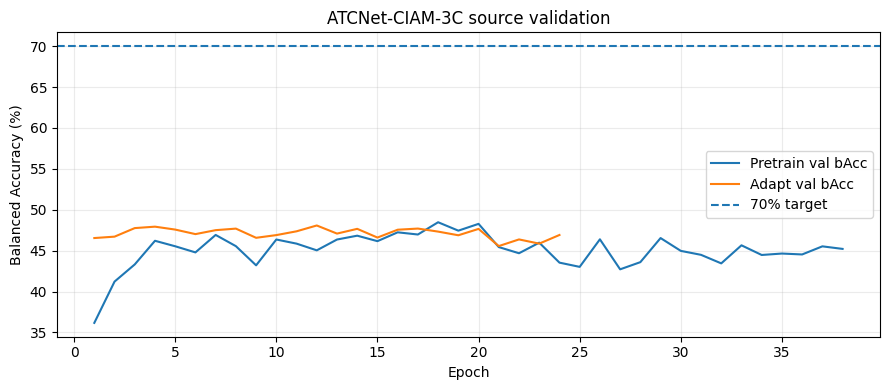

In [42]:
# ============================================================
# CELL 18 — TRAINING CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(9, 4)
)

if len(pre_history):
    ax.plot(
        pre_history["epoch"],
        pre_history["val_bacc"],
        label="Pretrain val bAcc"
    )

if len(adapt_history):
    ax.plot(
        adapt_history["epoch"],
        adapt_history["val_bacc"],
        label="Adapt val bAcc"
    )

ax.axhline(
    70,
    linestyle="--",
    label="70% target"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Balanced Accuracy (%)")
ax.set_title(
    "ATCNet-CIAM-3C source validation"
)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()


In [43]:
# ============================================================
# CELL 19 — SAVE RESULTS
# ============================================================

ATC_OUTPUT_DIR = (
    RESULTS_ROOT
    / "module_7_atcnet_ciam_3c"
)

ATC_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

subject_results.to_csv(
    ATC_OUTPUT_DIR
    / "bci_subject_results.csv",
    index=False
)

sample_results.to_csv(
    ATC_OUTPUT_DIR
    / "bci_sample_predictions.csv",
    index=False
)

pre_history.to_csv(
    ATC_OUTPUT_DIR
    / "pretraining_history.csv",
    index=False
)

adapt_history.to_csv(
    ATC_OUTPUT_DIR
    / "adaptation_history.csv",
    index=False
)

torch.save(
    {
        "model_state_dict":
            adapt_model.state_dict(),
        "classes":
            CLASSES,
        "architecture":
            "ATCNet-CIAM-3C",
        "input_shape":
            [22, 640],
        "sampling_rate_hz":
            float(TARGET_SFREQ),
    },
    ATC_OUTPUT_DIR
    / "atcnet_ciam_3c.pt"
)

summary = {
    "architecture":
        "ATCNet-CIAM-3C",

    "source_dataset":
        SOURCE_DATASET,

    "source_subjects":
        109,

    "target_dataset":
        TARGET_DATASET,

    "target_subjects":
        9,

    "overall_accuracy":
        float(overall_acc),

    "overall_balanced_accuracy":
        float(overall_bacc),

    "mean_subject_accuracy":
        float(
            subject_results[
                "accuracy"
            ].mean()
        ),

    "subjects_ge_70":
        int(
            (
                subject_results[
                    "accuracy"
                ]
                >= 70.0
            ).sum()
        ),

    "classes":
        CLASSES,

    "input_shape":
        [22, 640],

    "sampling_rate_hz":
        float(TARGET_SFREQ),
}

with open(
    ATC_OUTPUT_DIR
    / "summary.json",
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=2
    )

print(
    "Saved ATCNet-CIAM results to:"
)

print(
    ATC_OUTPUT_DIR
)


Saved ATCNet-CIAM results to:
/Users/ashokvarmabevara/Project2/cross_dataset_mi_project/results/module_7_atcnet_ciam_3c


In [44]:
# ============================================================
# CELL 20 — FINAL TARGET DECISION
# ============================================================

print("=" * 78)
print(
    "ATCNet-CIAM-3C — TARGET DECISION"
)
print("=" * 78)

print(
    f"Source subjects : 109 EEGMMIDB"
)

print(
    f"Target subjects : 9 BCI-IV-2a"
)

print(
    f"Overall acc     : {overall_acc:.2f}%"
)

print(
    f"Overall bAcc    : {overall_bacc:.2f}%"
)

if overall_acc >= 80.0:

    print(
        "\n✅ 80% TARGET ACHIEVED"
    )

elif overall_acc >= 70.0:

    print(
        "\n🟡 70% TARGET ACHIEVED; "
        "80% TARGET NOT YET ACHIEVED"
    )

else:

    print(
        "\n❌ TARGET NOT YET ACHIEVED"
    )

print(
    "\nImportant: these BCI labels were used only "
    "for final evaluation."
)


ATCNet-CIAM-3C — TARGET DECISION
Source subjects : 109 EEGMMIDB
Target subjects : 9 BCI-IV-2a
Overall acc     : 52.16%
Overall bAcc    : 52.16%

❌ TARGET NOT YET ACHIEVED

Important: these BCI labels were used only for final evaluation.


In [45]:
# ============================================================
# CELL 21 — OPTIONAL: NO-DOMAIN-ADAPTATION ATCNET BASELINE
# ============================================================
# This is useful for the paper: compare ATCNet-CIAM before and
# after DANN+MMD+CORAL using exactly the same source model.

P_bci_pre, _ = predict_atcnet(
    pre_model,
    X_target_n
)

pred_bci_pre = P_bci_pre.argmax(1)

baseline_acc = (
    accuracy_score(
        y_target,
        pred_bci_pre
    )
    * 100.0
)

baseline_bacc = (
    balanced_accuracy_score(
        y_target,
        pred_bci_pre
    )
    * 100.0
)

print(
    "ATCNet-CIAM before adaptation:"
)
print(
    f"  BCI accuracy : {baseline_acc:.2f}%"
)
print(
    f"  BCI bAcc     : {baseline_bacc:.2f}%"
)

print(
    "\nAfter DANN + MMD + CORAL:"
)
print(
    f"  BCI accuracy : {overall_acc:.2f}%"
)
print(
    f"  BCI bAcc     : {overall_bacc:.2f}%"
)

print(
    "\nAdaptation delta:"
)
print(
    f"  Accuracy Δ   : {overall_acc - baseline_acc:+.2f} pp"
)
print(
    f"  bAcc Δ       : {overall_bacc - baseline_bacc:+.2f} pp"
)


ATCNet-CIAM before adaptation:
  BCI accuracy : 52.21%
  BCI bAcc     : 52.21%

After DANN + MMD + CORAL:
  BCI accuracy : 52.16%
  BCI bAcc     : 52.16%

Adaptation delta:
  Accuracy Δ   : -0.05 pp
  bAcc Δ       : -0.05 pp
